## SETUP

In [31]:
import os
import re
import json
import numpy as np
import pandas as pd
from collections import Counter

# NLP
import nltk
from nltk.tokenize import word_tokenize
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Evaluasi & Visualisasi
import cleanlab
import seaborn as sns
import matplotlib.pyplot as plt

In [32]:

# NLTK Resource
for resource in ['punkt', 'punkt_tab']:
    try:
        nltk.data.find(f'tokenizers/{resource}')
        print(f"{resource} sudah ada, skip download")
    except LookupError:
        print(f"Downloading {resource}...")
        nltk.download(resource)

SAVE_PATH = "./data"

# Dataset
DATASET_FILENAME = "Indo_FreeNutritiousMeals_Sentiment_X_2025.csv"
DATASET_FILE_PATH = os.path.join(SAVE_PATH, DATASET_FILENAME)

if os.path.exists(DATASET_FILE_PATH):
    print(f"File sudah ada, skip download")
else:
    from huggingface_hub import hf_hub_download
    
    os.makedirs(SAVE_PATH, exist_ok=True)
    
    path_to_file = hf_hub_download(
        repo_id="tasyapndya/free_nutritious_meals_sentiment_x_id_2025",
        filename=DATASET_FILENAME,
        repo_type="dataset",
        local_dir=SAVE_PATH,
        local_dir_use_symlinks=False,
    )
    
    print(f"Selesai! File tersimpan di: {path_to_file}")

# Slang Dictionary
SLANG_FILENAME = "colloquial-indonesian-lexicon.csv"
SLANG_FILE_PATH = os.path.join(SAVE_PATH, SLANG_FILENAME)

SLANG_URL = "https://raw.githubusercontent.com/nasalsabila/kamus-alay/master/colloquial-indonesian-lexicon.csv"

if os.path.exists(SLANG_FILE_PATH):
    print(f"Slang dictionary sudah ada, skip download")
else:
    print("Sedang mendownload slang dictionary...")
    import urllib.request

    urllib.request.urlretrieve(SLANG_URL, SLANG_FILE_PATH)

    print(f"Selesai! Slang dictionary tersimpan di: {SLANG_FILE_PATH}")

# Indonesian Dictionary
WORDS_FILENAME = "kata-dasar.txt"
WORDS_FILE_PATH = os.path.join(SAVE_PATH, WORDS_FILENAME)

WORDS_URL = "https://raw.githubusercontent.com/har07/PySastrawi/master/src/Sastrawi/Stemmer/data/kata-dasar.txt"

if os.path.exists(WORDS_FILE_PATH):
    print(f"Dataset kata bahasa indonesia sudah ada, skip download")

else:
    print("Sedang mendownload dataset kata bahasa Indonesia")
    import urllib.request

    urllib.request.urlretrieve(WORDS_URL, WORDS_FILE_PATH)

    print(f"Selesai, Dataset kata bahasa indonesia tersimpan di {WORDS_FILE_PATH}")

# pd.set_option('display.max_colwidth', None)

punkt sudah ada, skip download
punkt_tab sudah ada, skip download
File sudah ada, skip download
Slang dictionary sudah ada, skip download
Dataset kata bahasa indonesia sudah ada, skip download


## Exploratory Data Analysis

Preview Top 15

In [33]:

df = pd.read_csv("data/Indo_FreeNutritiousMeals_Sentiment_X_2025.csv")
df.head(5).style.set_properties(**{'text-align': 'left'})

,cleaned_text,label
0,dari kementrian keuangan ke badan gizi nasional mana cair itu duit tanpa perintah prabowo mana ada makan beracun gratis ehh salah maksudnya makan bergizi gratis tanpa program yg digagas prabowo pejabat atas nama pemerintah menggunakan,negatif
1,koq ada bakteri e coli itu biasanya byk dikotoran manusia apa jgn2 makan bergizi gratis itu dicampur dgn,negatif
2,program makan bergizi gratis makin keren karena gerakan nyata bgn fokus ke distribusi makanan yang aman dan mutu terjamin,positif
3,no makan bergizi gratis yang bermasalah mitra mbg tersebut sudah diberikan sanksi dan ditutup lanjutkan mbg,netral
4,dukung program makan bergizi gratis,positif


Missing Values

In [35]:
missing_values = df.isna().sum()
print(f"Jumlah missing values: {missing_values}")

Jumlah missing values: cleaned_text    0
label           2
dtype: int64


In [36]:
df = df.dropna(subset=['label'])
missing_values = df.isna().sum()
print(f"Jumlah missing values: {missing_values}")

Jumlah missing values: cleaned_text    0
label           0
dtype: int64


Duplicates

In [37]:
num_duplicates = df.duplicated().sum()
print(f"Jumlah baris duplikat: {num_duplicates}")

Jumlah baris duplikat: 0


Label Distribution

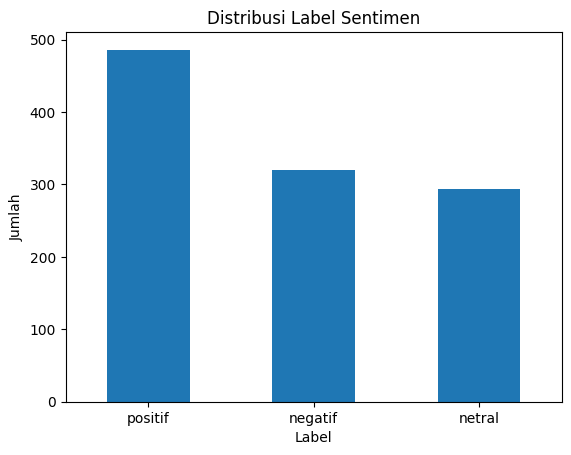

In [38]:

df['label'].value_counts().plot(kind='bar')

plt.title("Distribusi Label Sentimen")
plt.xlabel("Label")
plt.xticks(rotation=0)
plt.ylabel("Jumlah")
plt.show()

## Hashtag Analysis

In [39]:

def get_long_words(text, min_len=14):
    if not isinstance(text, str):
        return []
    return [word for word in text.split() if len(word) >= min_len]


long_words_series = df['cleaned_text'].apply(get_long_words)

all_long_words = [word for words in long_words_series for word in words]
freq = Counter(all_long_words)

df_long_words = pd.DataFrame(freq.items(), columns=['kata', 'frekuensi'])
df_long_words['panjang'] = df_long_words['kata'].str.len()
df_long_words = df_long_words.sort_values('frekuensi', ascending=False).reset_index(drop=True)

print(f"Jumlah kata unik dengan panjang >= 14 huruf: {len(df_long_words)}")
print(df_long_words[['kata', 'frekuensi', 'panjang']].to_string())

Jumlah kata unik dengan panjang >= 14 huruf: 143
                                kata  frekuensi  panjang
0                 makanbergizigratis         78       18
1                     pemerataangizi         23       14
2                enambulanpemerintah         20       19
3                penuhigiziindonesia         18       19
4                  indonesiaemas2045         12       17
5                   dukungprogrammbg          9       16
6                    giziuntukbangsa          6       15
7                     indonesiagelap          5       14
8                    bhabinkamtibmas          5       15
9                    mbgmajukanpapua          5       15
10                   prabowosubianto          5       15
11                    papuaindonesia          5       14
12                 peringatandarurat          4       17
13                    indonesiasehat          4       14
14                    faktaindonesia          3       14
15                   pendistribusian   

In [40]:
with open("./data/kata-dasar.txt", "r") as f:
    kamus = set(f.read().splitlines())

print(f"Jumlah kata dasar: {len(kamus):,}")
print(f"Contoh: {list(kamus)[:10]}")

Jumlah kata dasar: 29,932
Contoh: ['temaram', 'tanbihat', 'juih', 'pelinggam', 'pengaruh', 'bas', 'durnoisme', 'ariningsun', 'nonol', 'psikosomatik']


In [41]:

factory = StemmerFactory()
stemmer = factory.create_stemmer()

whitelist = {
    'bhabinkamtibmas', 
    'mendikdasmen',   
    'ketenagakerjaan',
    'ketahananpangan',
    'ketidakpastian',
    'ketidakpercayaan',
    'mengalilipatkan',
    'menindaklanjuti',
    'ditindaklanjuti',
    'maladministrasi',
    'djojohadikusumo',
    'higienietasnya',
    'independensinya',
    "fahriansalehsiregar",
    "gastrokolonialisme"

}

def classify_long_word(word, kamus, stemmer, whitelist):
    if word in whitelist:
        return 'valid'
    if word in kamus:
        return 'valid'
    if stemmer.stem(word) in kamus:
        return 'valid'
    return 'hashtag'

df_long_words['status'] = df_long_words['kata'].apply(
    lambda w: classify_long_word(w, kamus, stemmer, whitelist)
)

print(df_long_words['status'].value_counts())
print()
print("=== KANDIDAT HASHTAG ===")
print(df_long_words[df_long_words['status'] == 'hashtag'].to_string())
print()
print("=== KATA VALID ===")
print(df_long_words[df_long_words['status'] == 'valid'].to_string())

status
hashtag    104
valid       39
Name: count, dtype: int64

=== KANDIDAT HASHTAG ===
                                kata  frekuensi  panjang   status
0                 makanbergizigratis         78       18  hashtag
1                     pemerataangizi         23       14  hashtag
2                enambulanpemerintah         20       19  hashtag
3                penuhigiziindonesia         18       19  hashtag
4                  indonesiaemas2045         12       17  hashtag
5                   dukungprogrammbg          9       16  hashtag
6                    giziuntukbangsa          6       15  hashtag
7                     indonesiagelap          5       14  hashtag
9                    mbgmajukanpapua          5       15  hashtag
10                   prabowosubianto          5       15  hashtag
11                    papuaindonesia          5       14  hashtag
12                 peringatandarurat          4       17  hashtag
13                    indonesiasehat          4      

## Text Preprocessing

In [42]:

# A. Membaca dictionary slang
SLANG_FILE_PATH = './data/colloquial-indonesian-lexicon.csv'
slang_df = pd.read_csv(SLANG_FILE_PATH)
slang_dict = dict(zip(slang_df.iloc[:, 0], slang_df.iloc[:, 1]))

# B. Membaca file hashtag JSON
with open('./data/hashtag.json', 'r') as file:
    hashtag_dict = json.load(file)

# C. Membuat Dictionary Gabungan (Hashtag menimpa slang jika ada konflik)
master_dict = {**slang_dict, **hashtag_dict}

# D. Setup Sastrawi Stopword (Dengan pengamanan negasi)
stop_factory = StopWordRemoverFactory()
default_stopwords = stop_factory.get_stop_words()

# Daftar kata yang TIDAK BOLEH dihapus karena krusial untuk sentimen
negation_words = ['tidak', 'bukan', 'jangan', 'kurang', 'belum']
# Membuat list stopword baru tanpa kata negasi
custom_stopwords = [word for word in default_stopwords if word not in negation_words]

# E. Setup Sastrawi Stemmer
stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()

# 2. FUNGSI PREPROCESSING

# Case Folding
def case_folding(text):
    if pd.isna(text):
        return text
    return str(text).lower()

# Menghapus error encoding
def remove_encoding_noise(text):
    if pd.isna(text):
        return text
    text = re.sub(r'_x[0-9a-fA-F]+_', ' ', text)  # hapus pola _x0000_
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)    # hapus karakter aneh (non-ASCII)
    return text

# Normalisasi slang dan hashtag
def normalize_all(text, master_dictionary):
    if pd.isna(text): return text
    
    words = text.split()
    normalized_words = [master_dictionary.get(word, word) for word in words if master_dictionary.get(word, word) != ""]
    
    return " ".join(normalized_words)

# Tokenization
def tokenize_text(text):
    if pd.isna(text): return text
    return word_tokenize(text)

# Stopword Removal
def remove_stopwords(tokens):
    if not isinstance(tokens, list): return tokens
    return [word for word in tokens if word not in custom_stopwords]

# Stemming
def stem_text(text):
    if pd.isna(text): return text
    # Sastrawi menerima input berupa string kalimat, bukan list token
    return stemmer.stem(text)

# 3. MAIN PIPELINE

# Apply all
def preprocesing_text(text):
    text = case_folding(text)
    text = remove_encoding_noise(text)    
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', str(text)) 
    text = normalize_all(text, master_dict)
    text = re.sub(r'\s+', ' ', text).strip()
    
    tokens = tokenize_text(text)
    tokens_no_stopword = remove_stopwords(tokens)
    text_joined = " ".join(tokens_no_stopword)
    final_text = stem_text(text_joined)
    
    return final_text


In [43]:
df_preprocessed = df.copy()
df_preprocessed['cleaned_text'] = df_preprocessed['cleaned_text'].apply(preprocesing_text)

In [44]:
df_preprocessed.head(5).style.set_properties(**{'text-align': 'left'})

,cleaned_text,label
0,tri uang badan gizi nasional cair duit perintah prabowo makan racun gratis eh salah maksud makan gizi gratis program gagas prabowo jabat nama perintah,negatif
1,bakteri coli kotor manusia jangan makan gizi gratis campur,negatif
2,program makan gizi gratis keren gera badan gizi nasional fokus distribusi makan aman mutu jamin,positif
3,no makan gizi gratis masalah mitra makan gizi gratis sanksi tutup lanjut makan gizi gratis,netral
4,dukung program makan gizi gratis,positif


## Mislabel Handling

In [45]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_val_predict
from sklearn.svm import SVC
import cleanlab


# 1. Transformasi Teks Sementara
vectorizer_cl = TfidfVectorizer()
X_cl = vectorizer_cl.fit_transform(df_preprocessed['cleaned_text'])

label_mapping = {'negatif': 0, 'netral': 1, 'positif': 2}
y_cl = df['label'].map(label_mapping).values

# 2. Inisialisasi Model SVM dengan probability=True
svm_cl = SVC(kernel='linear', probability=True, random_state=42)

# 3. Dapatkan probabilitas 'Out-of-Sample' menggunakan Cross Validation
print("Sedang menghitung probabilitas cross-validation...")
pred_probs = cross_val_predict(
    estimator=svm_cl, 
    X=X_cl, 
    y=y_cl, 
    cv=5, 
    method='predict_proba'
)

print("Sedang mencari kandidat mislabel...")
label_issues_indices = cleanlab.filter.find_label_issues(
    labels=y_cl,
    pred_probs=pred_probs,
    return_indices_ranked_by='self_confidence' # Diurutkan dari yang paling parah salahnya
)

print(f"Cleanlab menemukan {len(label_issues_indices)} kandidat data mislabel.")

df_issues = df_preprocessed.iloc[label_issues_indices].copy()
predicted_labels = np.argmax(pred_probs, axis=1)
reverse_mapping = {0: 'negatif', 1: 'netral', 2: 'positif'}
df_issues['prediksi_cleanlab'] = [reverse_mapping[pred] for pred in predicted_labels[label_issues_indices]]


display(df_issues[['cleaned_text', 'label', 'prediksi_cleanlab']].head(5))



Sedang menghitung probabilitas cross-validation...
Sedang mencari kandidat mislabel...
Cleanlab menemukan 258 kandidat data mislabel.


,cleaned_text,label,prediksi_cleanlab
41,program makan gizi gratis penuh gizi anak anak penuh gizi indonesia,negatif,positif
40,program makan gizi gratis penuh gizi anak anak indonesia emas 2045 penuh gizi indonesia,negatif,positif
140,makan gizi gratis langkah perintah sejahtera rakyat indonesia emas 2045 indonesia manfaat makan gizi gratis dukung makan gizi gratis,negatif,positif
22,dukung program makan gizi gratis makan gizi gratis makan gizi gratis perata gizi,negatif,positif
611,danantara dukung program makan gizi gratis sehat anak anak indonesia indonesia makan gizi gratis makanbergizi anaksehat investasi bangsa,netral,positif


In [46]:

# 1. BUAT KOPIAN DATASET ASLI
df_final = df_preprocessed.copy()

# 2. LOAD FILE REKOMENDASI
df_recommend = pd.read_csv('./data/kandidat_mislabel_rekomendasi.csv')

# 3. FILTER HANYA DATA YANG HARUS DIUBAH
df_temp = df_recommend[df_recommend['Rekomendasi_Aksi'].str.startswith('Ubah ke')].copy()
df_temp['label_baru'] = df_temp['Rekomendasi_Aksi'].str.replace('Ubah ke ', '')

sum_changes = 0

for _, row in df_temp.iterrows():
    idx = row['Unnamed: 0']
    new_label = row['label_baru']
    
    df_final.loc[idx, 'label'] = new_label
    sum_changes += 1

print(f"✅ Selesai! Berhasil mengubah {sum_changes} label yang salah.")

print("\nDistribusi Label Asli:")
print(df['label'].value_counts())

print("\nDistribusi Label Setelah Dibersihkan:")
print(df_final['label'].value_counts())

✅ Selesai! Berhasil mengubah 130 label yang salah.

Distribusi Label Asli:
label
positif    486
negatif    320
netral     294
Name: count, dtype: int64

Distribusi Label Setelah Dibersihkan:
label
positif    473
netral     338
negatif    289
Name: count, dtype: int64


In [47]:

df_final = df_final.dropna(subset=['cleaned_text', 'label'])


X = df_final['cleaned_text']
y = df_final['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Jumlah Data Latih: {X_train.shape[0]}")
print(f"Jumlah Data Uji: {X_test.shape[0]}")

Jumlah Data Latih: 880
Jumlah Data Uji: 220


## TF-IDF

In [48]:
vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Jumlah Fitur (Vocabulary) TF-IDF: {X_train_tfidf.shape[1]} kata unik")

Jumlah Fitur (Vocabulary) TF-IDF: 2387 kata unik


## Modeling SVM


Sedang melatih model SVM...

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     negatif       0.84      0.72      0.78        58
      netral       0.71      0.78      0.74        68
     positif       0.88      0.89      0.89        94

    accuracy                           0.81       220
   macro avg       0.81      0.80      0.80       220
weighted avg       0.82      0.81      0.81       220



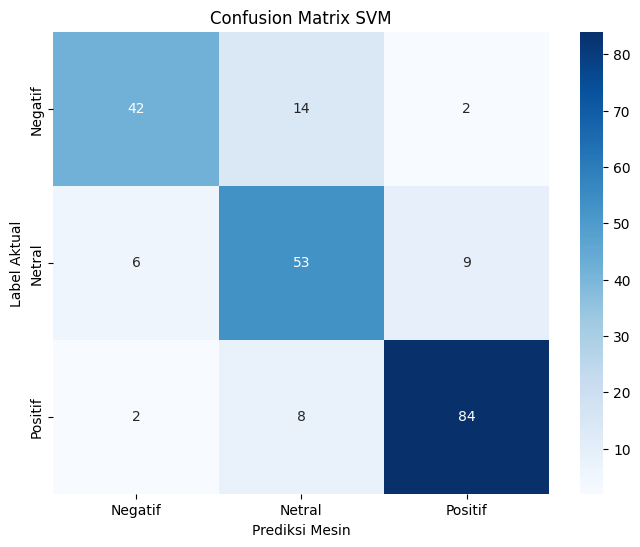

In [49]:
print("\nSedang melatih model SVM...")


svm_model = SVC(kernel='linear', class_weight='balanced', random_state=42)
svm_model.fit(X_train_tfidf, y_train)

y_pred = svm_model.predict(X_test_tfidf)

# --- EVALUASI HASIL ---
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=['negatif', 'netral', 'positif'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negatif', 'Netral', 'Positif'], 
            yticklabels=['Negatif', 'Netral', 'Positif'])
plt.title('Confusion Matrix SVM')
plt.xlabel('Prediksi Mesin')
plt.ylabel('Label Aktual')
plt.show()

## Visualisasi Hasil Temuan

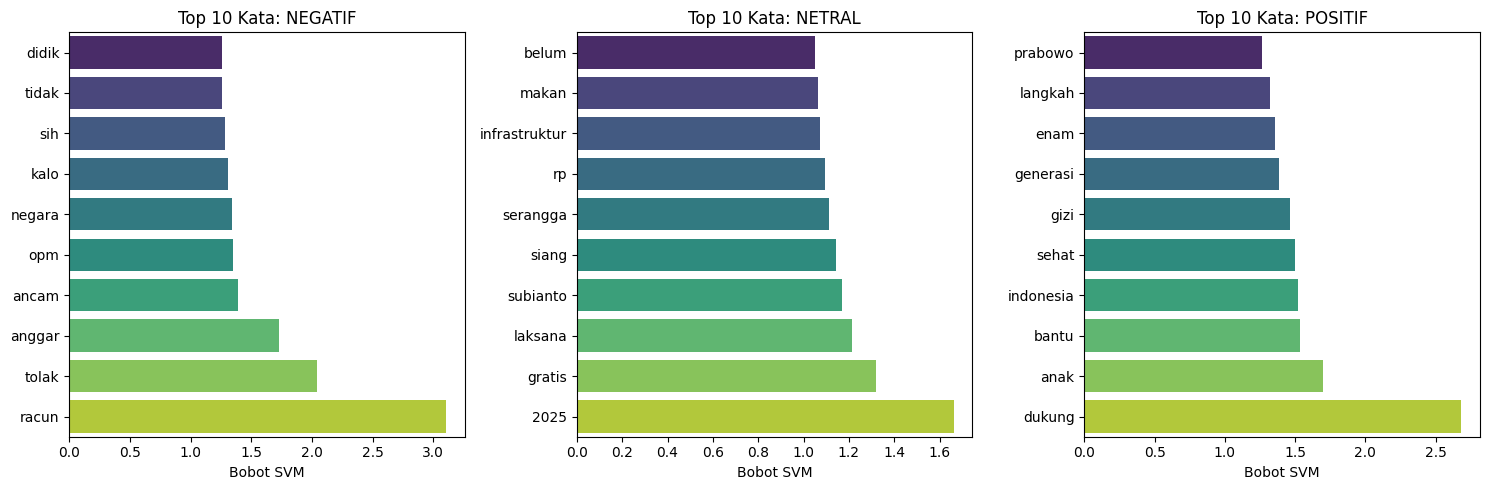

In [50]:
from sklearn.svm import LinearSVC
import numpy as np

svm_explainer = LinearSVC(class_weight='balanced', random_state=42)
svm_explainer.fit(X_train_tfidf, y_train)

words = np.array(vectorizer.get_feature_names_out())

plt.figure(figsize=(15, 5))

for i, kelas in enumerate(svm_explainer.classes_):
    top10_idx = np.argsort(svm_explainer.coef_[i])[-10:]
    top10_word = words[top10_idx]
    top10_weight = svm_explainer.coef_[i][top10_idx]

    # Plotting
    plt.subplot(1, 3, i+1)
    sns.barplot(x=top10_weight, y=top10_word, hue=top10_word, legend=False, palette='viridis')
    plt.title(f'Top 10 Kata: {kelas.upper()}')
    plt.xlabel('Bobot SVM')

plt.tight_layout()
plt.show()

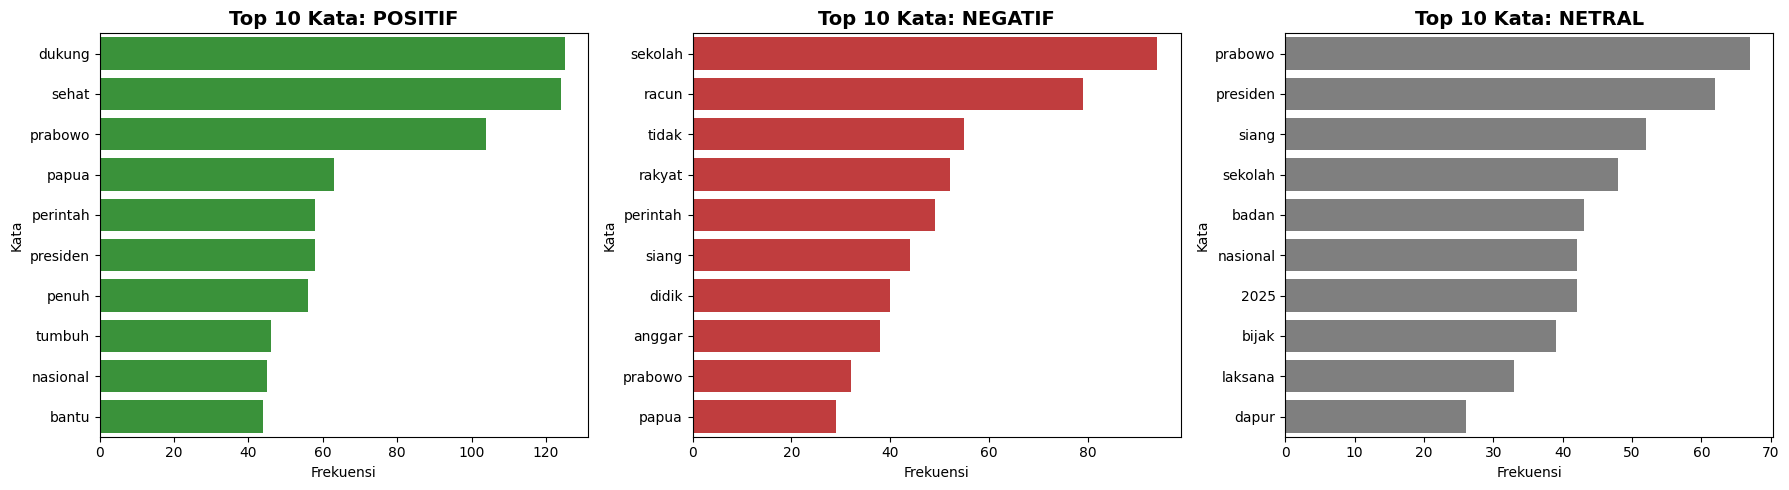

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

domain_stopwords = {'makan', 'gizi', 'gratis', 'program', 'mbg', 'indonesia', 'anak'}
def hapus_domain_stopword(teks):
    words = teks.split()
    words_cleaned = [word for word in words if word not in domain_stopwords]
    return " ".join(words_cleaned)

labels = ['positif', 'negatif', 'netral']
colors_bar = ['#2ca02c', '#d62728', '#7f7f7f']
colormaps_wc = ['Greens', 'Reds', 'Greys']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, label in enumerate(labels):
    combined_text = " ".join(df_final[df_final['label'] == label]['cleaned_text'])
    combined_text_cleaned = hapus_domain_stopword(combined_text)
    word_counts = Counter(combined_text_cleaned.split())
    top_10 = word_counts.most_common(10)
    word = [w[0] for w in top_10]
    freq = [w[1] for w in top_10]
    sns.barplot(x=freq, y=word, ax=axes[i], color=colors_bar[i])
    axes[i].set_title(f'Top 10 Kata: {label.upper()}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Frekuensi')
    axes[i].set_ylabel('Kata')

plt.tight_layout()
plt.show()


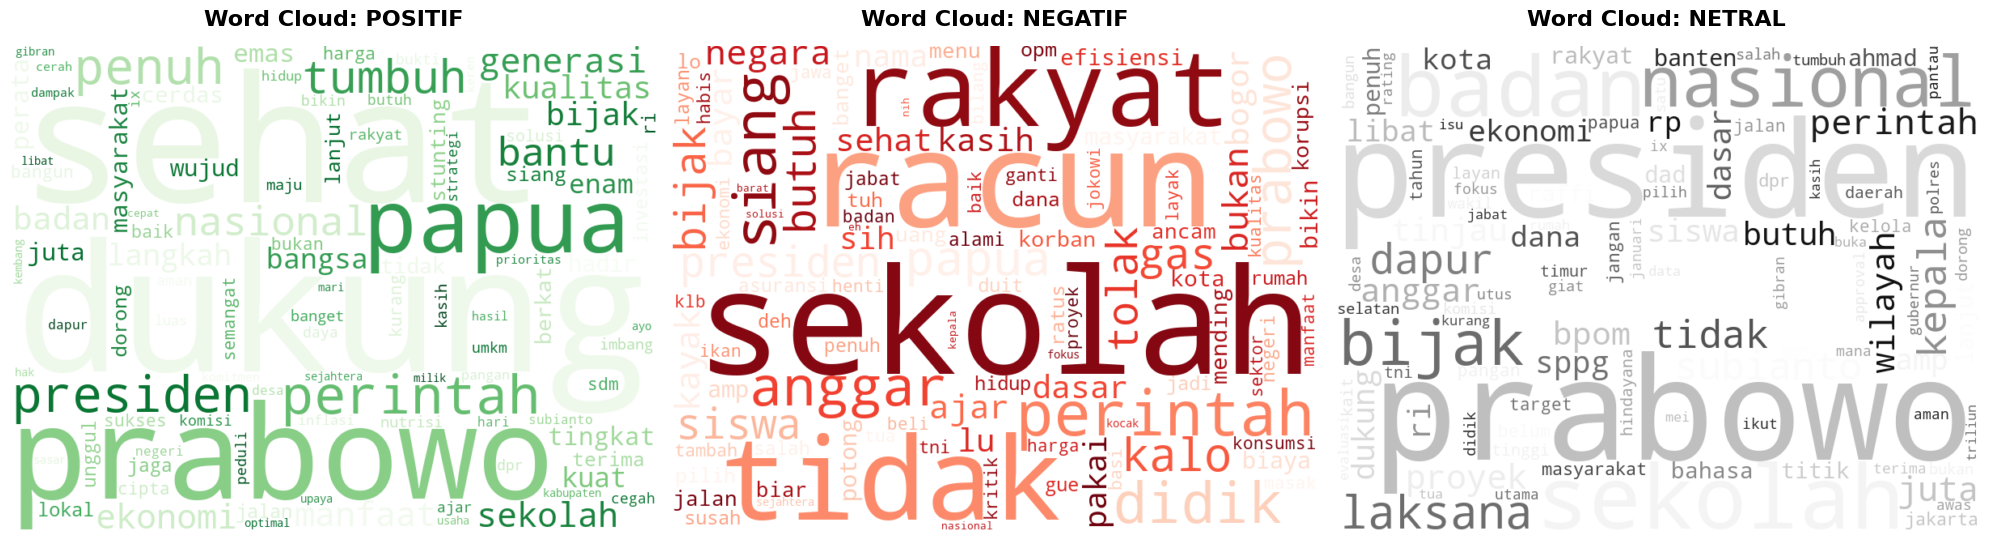

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, label in enumerate(labels):
    combined_text = " ".join(df_final[df_final['label'] == label]['cleaned_text'])
    combined_text_cleaned = hapus_domain_stopword(combined_text)

    wordcloud = WordCloud(
        width=800,
        height=600,
        background_color='white',
        colormap=colormaps_wc[i],
        max_words=100,
        contour_width=1,
        contour_color='black',
        collocations=False
    ).generate(combined_text_cleaned)
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(f'Word Cloud: {label.upper()}', fontsize=16, fontweight='bold', pad=15)
    axes[i].axis('off')

plt.tight_layout()
plt.show()